Mean of group a  3943.3846153846152
Mean of group b 5529.022695035461
Diff -1585.6380796508456


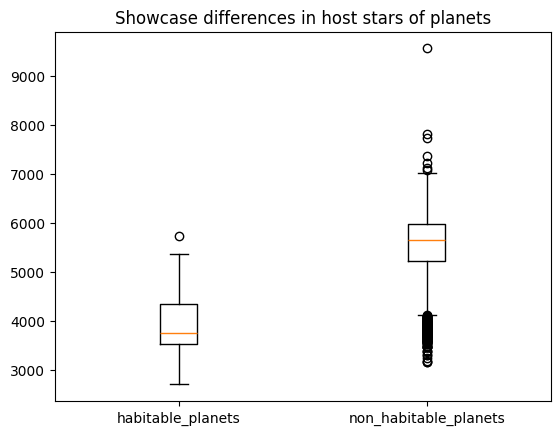

perm diffs [138.46618658 182.93728314  -7.76342608 ... 218.45239498 110.5173377
  82.18245499]
P_value :  0.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Please move to /reports/claim-3.md to read to final claim of this project

df = pd.read_csv("../data/raw/kepler.csv")

#Group A : host star of habitable planets
#Group B: host star of non habitable planets
habitable_planets = df[df['is_habitable']==True]
non_habitable_planets = df[df['is_habitable']==False]
group_a = habitable_planets['koi_steff'].dropna().values
group_b = non_habitable_planets['koi_steff'].dropna().values

mean_a = np.mean(group_a)
mean_b = np.mean(group_b)
diff_obs = mean_a-mean_b
print("Mean of group a ",mean_a)
print("Mean of group b",mean_b)
print("Diff",diff_obs)

plt.boxplot([group_a,group_b],tick_labels=['habitable_planets','non_habitable_planets'])
plt.title("Showcase differences in host stars of planets")
plt.show()

#Method i'll use : permutation test
all_data = np.concatenate([group_a,group_b])
n_a =len(group_a)
perm_nb = 5000
diffs=[]

for _ in range(perm_nb): 
    shuffled_data = np.random.permutation(all_data)
    a = shuffled_data[:n_a]
    b = shuffled_data[n_a:]
    diff = np.mean(a)-np.mean(b)
    diffs.append(diff)

diffs = np.array(diffs)
print("perm diffs",diffs)
p_value = np.mean(np.abs(diffs)>=np.abs(diff_obs))

print("P_value : ",p_value)

